In [1]:
import geopandas as gpd

real_subsidence = gpd.read_file("../../assets/real_subsidence_pointbased.gpkg")
print(real_subsidence.columns)

Index(['west', 'east', 'north', 'south', 'location', 'val', 'geometry'], dtype='str')


In [2]:

# importing the poackages for the EGMS API
import sys
import json
import time
import requests
import jwt
import cryptography

In [3]:
# copy the token retrieval from file from the egms notebook

def get_access_token(path):
    service_key = json.load(open(path, 'rb'))
    private_key = service_key['private_key'].encode('utf-8')
    claim_set = {
        "iss": service_key['client_id'],
        "sub": service_key['user_id'],
        "aud": service_key['token_uri'],
        "iat": int(time.time()),
        "exp": int(time.time() + (60 * 60)),
    }
    grant = jwt.encode(claim_set, private_key, algorithm='RS256')
    result = requests.post(service_key["token_uri"], headers={ "Accept": "application/json", "Content-Type": "application/x-www-form-urlencoded" },
            data={ "grant_type": "urn:ietf:params:oauth:grant-type:jwt-bearer", "assertion": grant } )
    access_token_info_json = result.json()
    access_token = access_token_info_json.get('access_token')
    return access_token

# obtain the access token and configure the header
access_token = get_access_token("../../assets/token.jwt")
headers = {"Authorization" : f"Bearer {access_token}", "Accept" : "application/json"}

In [ ]:
# Get a list of levels, product releases, swaths, burst cycles, relative orbits and directions
api_endpoint = "https://egms.land.copernicus.eu/insar-api/archive"

info = { "levels" : requests.get(f"{api_endpoint}/levels", headers=headers).json(),
         "releases" : requests.get(f"{api_endpoint}/releases", headers=headers).json(),
         "swaths" : requests.get(f"{api_endpoint}/swaths", headers=headers).json(),
         "relative_orbits" : requests.get(f"{api_endpoint}/relative_orbits", headers=headers).json(),
         "bursts" : requests.get(f"{api_endpoint}/bursts", headers=headers).json(),
         "directions" : requests.get(f"{api_endpoint}/directions", headers=headers).json(),
         "tile_ids" : requests.get(f"{api_endpoint}/tile_ids", headers=headers).json(),
         "product_types" : requests.get(f"{api_endpoint}/product_types", headers=headers).json()
       }

for key, value in info.items():
    if type(value) == type({}):
        print(f"Error: {value}")
    else:
        print(f"Available {key}: {value[0:5]} {'...' if len(value) > 5 else ''}")

In [27]:

def get_access_token(token_path):
    # This is from the egms api repo https://github.com/copernicus-land/egms-api/blob/main/EGMS-API.ipynb
    service_key = json.load(open(token_path, 'rb'))
    private_key = service_key['private_key'].encode('utf-8')
    claim_set = {
        "iss": service_key['client_id'],
        "sub": service_key['user_id'],
        "aud": service_key['token_uri'],
        "iat": int(time.time()),
        "exp": int(time.time() + (60 * 60)),
    }
    grant = jwt.encode(claim_set, private_key, algorithm='RS256')
    result = requests.post(service_key["token_uri"], headers={ "Accept": "application/json", "Content-Type": "application/x-www-form-urlencoded" },
            data={ "grant_type": "urn:ietf:params:oauth:grant-type:jwt-bearer", "assertion": grant } )
    access_token_info_json = result.json()
    access_token = access_token_info_json.get('access_token')
    return access_token

def point_to_bbox(row, t2projected, t2wgs84):
    # reproject to appropriate crs
    # assumes that the correct projection is already set
    x, y = t2projected.transform(row.geometry.x, row.geometry.y)

    # compute the min/max values
    top_left_x = x - (row["west"] * 1000)
    top_left_y = y + (row["north"] * 1000)

    top_right_x = x + (row["east"] * 1000)
    top_right_y = y + (row["north"] * 1000)

    bottom_left_x = x - (row["west"] * 1000)
    bottom_left_y = y - (row["south"] * 1000)

    bottom_right_x = x + (row["east"] * 1000)
    bottom_right_y = y - (row["south"] * 1000)

    tl_lon, tl_lat = t2wgs84.transform(top_left_x, top_left_y)
    tr_lon, tr_lat = t2wgs84.transform(top_right_x, top_right_y)
    bl_lon, bl_lat = t2wgs84.transform(bottom_left_x, bottom_left_y)
    br_lon, br_lat = t2wgs84.transform(bottom_right_x, bottom_right_y)

    return [[tl_lon, tl_lat], [bl_lon, bl_lat], [br_lon, br_lat], [tr_lon, tr_lat]]

def query_egms(row, headers, api_endpoint = "https://egms.land.copernicus.eu/insar-api/archive"):
    
    query = {"id": None,
         "bbox": row["bbox"],
         "levels" : ["L2B"],
         "releases" : ["2019-2023"]
         }

    r = requests.post(f"{api_endpoint}/search", headers=headers, data=json.dumps(query))
    result = r.json()

    # Constructing a download link for all the products in the result
    # code from the egms api repo
    links = []
    for hit in result["hits"]:
        link = f"{api_endpoint}/download/{hit['filename']}?id={result['id']}"
        links.append(link)

    return result, links
    

def pull_egms(row, headers):
    # some of the real subsidence areas go into training but some also go into validation
    save_path = PROJECT_DIR / "data/egms" / ("val" if row["val"] == 1 else "train") / row["location"]
    save_path.mkdir(parents=True, exist_ok=True)

    for link, hit in zip(row["download_links"], row["query_results"]["hits"]):
         filename = hit["filename"]
         with requests.get(link, headers=headers, stream=True) as r:
            r.raise_for_status()
            with open(save_path / filename, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    f.write(chunk)

In [ ]:

# Compute the bounding boxes for every real subsidence region
t2projected = Transformer.from_crs(real_subsidence.crs, "EPSG:3035", always_xy=True)
t2wgs84 = Transformer.from_crs("EPSG:3035", "EPSG:4326", always_xy=True)
real_subsidence["bbox"] = real_subsidence.apply(point_to_bbox, axis=1, result_type="reduce", t2projected=t2projected, t2wgs84=t2wgs84)

# get the access token for the egms api
access_token = get_access_token("../../assets/token.jwt")
headers = {"Authorization" : f"Bearer {access_token}", "Accept" : "application/json"}

real_subsidence[["query_results", "download_links"]] = real_subsidence.apply(query_egms, axis=1, headers=headers, result_type = "expand")



In [47]:
#row = real_subsidence.iloc[0]["query_results"]["hits"][0]
row = real_subsidence.iloc[0]

print(row)
print(row["query_results"]["hits"])








west                                                             15
east                                                             15
north                                                            10
south                                                            10
location                                                     Napoli
val                                                               1
geometry               POINT (14.174602734902047 40.86099118221181)
bbox              [[14.003417147161144, 40.95861312799598], [13....
query_results     {'status': True, 'hits': [{'poly': [[13.263518...
download_links    [https://egms.land.copernicus.eu/insar-api/arc...
Name: 0, dtype: object
[{'poly': [[13.26351828694517, 40.5725314512021], [13.21551321585416, 40.75955606420097], [14.22290596756674, 40.90217503570774], [14.2679581987243, 40.71511602242241]], 'bbox': [[13.21551321585416, 40.5725314512021], [14.2679581987243, 40.90217503570774]], 'path': '2019-2023/L2B/A24-044/EGMS_L2b

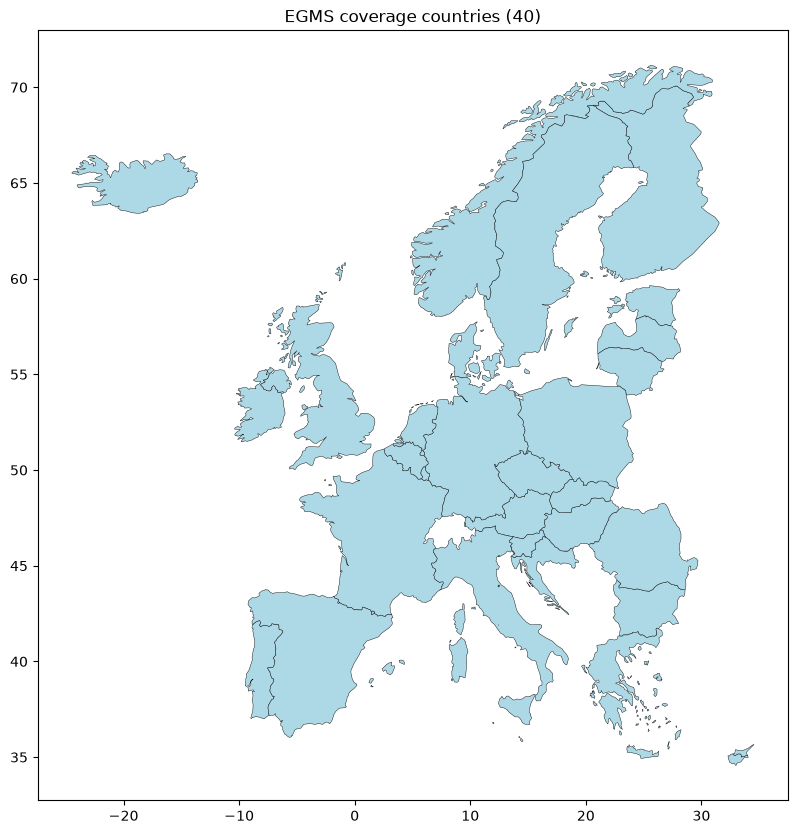

['Andorra', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Guernsey', 'Hungary', 'Iceland', 'Ireland', 'Isle of Man', 'Italy', 'Jersey', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Monaco', 'N. Cyprus', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'San Marino', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'United Kingdom', 'Vatican', 'Åland']


In [50]:
import geopandas as gpd
import matplotlib.pyplot as plt

coverage = gpd.read_file("../../assets/egms_coverage_countries.geojson")

fig, ax = plt.subplots(figsize=(10, 10))
coverage.plot(ax=ax, facecolor="lightblue", edgecolor="black", linewidth=0.3)
ax.set_title(f"EGMS coverage countries ({len(coverage)})")
plt.show()

print(sorted(coverage["name"].tolist()))
